감지된 신호등 색상: Green


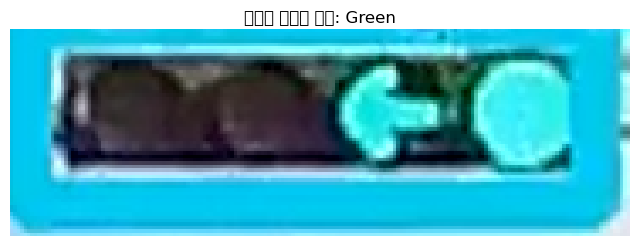

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 이미지 불러오기 (파일명을 실제 파일명으로 바꿔주세요)
image_path = 'traffic_light.png'
img_bgr = cv2.imread(image_path)

if img_bgr is None:
    raise ValueError("이미지를 불러올 수 없습니다. 경로를 확인하세요.")

# BGR -> HSV 변환
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

# 색상 범위 정의 (HSV 기준)
color_ranges = {
    'Red': [
        (np.array([0, 100, 100]), np.array([10, 255, 255])),
        (np.array([160, 100, 100]), np.array([180, 255, 255]))
    ],
    'Yellow': [
        (np.array([15, 100, 100]), np.array([35, 255, 255]))
    ],
    'Green': [
        (np.array([40, 100, 100]), np.array([90, 255, 255]))
    ]
}

# 색상별 마스크 및 픽셀 수 계산
color_pixels = {}
for color, ranges in color_ranges.items():
    mask = np.zeros(img_hsv.shape[:2], dtype=np.uint8)
    for lower, upper in ranges:
        mask |= cv2.inRange(img_hsv, lower, upper)
    color_pixels[color] = cv2.countNonZero(mask)

# 가장 많은 픽셀을 가진 색상 감지
detected_color = max(color_pixels, key=color_pixels.get)
print(f"감지된 신호등 색상: {detected_color}")

# 결과 시각화
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 4))
plt.imshow(img_rgb)
plt.title(f"감지된 신호등 색상: {detected_color}")
plt.axis('off')
plt.show()

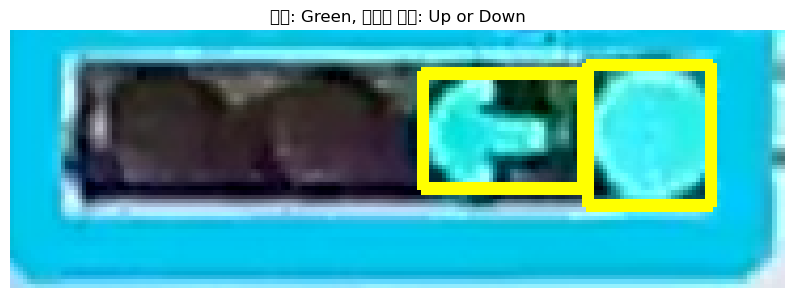

색상: Green, 화살표 방향: Up or Down


In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. 이미지 불러오기
image_path = 'traffic_light.png'
img = cv2.imread(image_path)
if img is None:
    raise ValueError("이미지를 불러올 수 없습니다. 경로를 확인하세요.")

# 2. 색상 감지를 위한 HSV 변환
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# 색상 범위 설정
def create_mask(hsv_img, lower, upper):
    return cv2.inRange(hsv_img, lower, upper)

# 빨간색
mask_red1 = create_mask(hsv, np.array([0, 100, 100]), np.array([10, 255, 255]))
mask_red2 = create_mask(hsv, np.array([160, 100, 100]), np.array([180, 255, 255]))
mask_red = cv2.bitwise_or(mask_red1, mask_red2)

# 노란색
mask_yellow = create_mask(hsv, np.array([15, 100, 100]), np.array([35, 255, 255]))

# 초록색
mask_green = create_mask(hsv, np.array([40, 100, 100]), np.array([90, 255, 255]))

# 색상 판별
colors = {
    'Red': cv2.countNonZero(mask_red),
    'Yellow': cv2.countNonZero(mask_yellow),
    'Green': cv2.countNonZero(mask_green),
}
main_color = max(colors, key=colors.get)

# 3. 화살표 탐지 (초록색 마스크 기반)
mask_arrow = mask_green.copy()
contours, _ = cv2.findContours(mask_arrow, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

arrow_direction = "None"
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > 100:  # 작으면 무시
        approx = cv2.approxPolyDP(cnt, 0.03 * cv2.arcLength(cnt, True), True)
        x, y, w, h = cv2.boundingRect(approx)
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 255), 2)

        # 간단한 방향 추정 (너비와 높이로 판단)
        if w > h:
            arrow_direction = "Right or Left"
        elif h > w:
            arrow_direction = "Up or Down"

# 4. 결과 출력
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
result_text = f"색상: {main_color}, 화살표 방향: {arrow_direction}"

plt.figure(figsize=(10, 5))
plt.imshow(img_rgb)
plt.title(result_text)
plt.axis('off')
plt.show()

print(result_text)


🔴 감지된 신호등 색상: Green
➡️  감지된 화살표 개수: 0


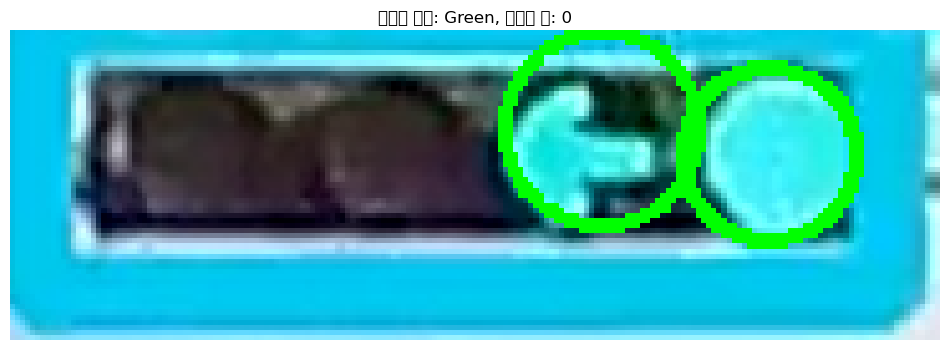

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 이미지 로드
image_path = 'traffic_light.png'
img = cv2.imread(image_path)
if img is None:
    raise ValueError("이미지를 불러올 수 없습니다.")

img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# 신호등 색상 감지
def detect_traffic_light_color(hsv_img):
    masks = {
        'Red': cv2.inRange(hsv_img, np.array([0, 100, 100]), np.array([10, 255, 255])) |
               cv2.inRange(hsv_img, np.array([160, 100, 100]), np.array([180, 255, 255])),
        'Yellow': cv2.inRange(hsv_img, np.array([15, 100, 100]), np.array([35, 255, 255])),
        'Green': cv2.inRange(hsv_img, np.array([40, 100, 100]), np.array([90, 255, 255]))
    }
    counts = {color: cv2.countNonZero(mask) for color, mask in masks.items()}
    detected = max(counts, key=counts.get)
    return detected, masks[detected]

# 화살표 감지
def detect_arrows(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blur, 60, 255, cv2.THRESH_BINARY_INV)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    arrows = []

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 300:
            continue
        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = w / h if h != 0 else 0
        bounding_area = w * h
        solidity = area / bounding_area if bounding_area > 0 else 0

        if 0.3 < aspect_ratio < 3.0 and 0.2 < solidity < 0.8:
            approx = cv2.approxPolyDP(cnt, 0.03 * cv2.arcLength(cnt, True), True)
            if len(approx) >= 7:
                arrows.append(cnt)

    return arrows

# 결과용 이미지 복사
img_result = img.copy()

# 1. 신호등 색상 및 원형 표시
color_name, color_mask = detect_traffic_light_color(img_hsv)
contours, _ = cv2.findContours(color_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > 300:
        (x, y), radius = cv2.minEnclosingCircle(cnt)
        center = (int(x), int(y))
        radius = int(radius)
        cv2.circle(img_result, center, radius, (0, 255, 0), 2)  # 초록 테두리 원

# 2. 화살표 탐지 및 삼각형 표시
arrow_contours = detect_arrows(img)

for cnt in arrow_contours:
    # 세모 표시: 윤곽선 중심점을 기준으로 삼각형
    M = cv2.moments(cnt)
    if M["m00"] == 0:
        continue
    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])
    size = 30  # 삼각형 크기
    triangle_cnt = np.array([
        [cx, cy - size],
        [cx - size, cy + size],
        [cx + size, cy + size]
    ])
    cv2.drawContours(img_result, [triangle_cnt], 0, (255, 0, 0), 2)  # 파란 세모

# 결과 출력
print(f"🔴 감지된 신호등 색상: {color_name}")
print(f"➡️  감지된 화살표 개수: {len(arrow_contours)}")

# 시각화
plt.figure(figsize=(12, 6))
plt.imshow(cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB))
plt.title(f"신호등 색상: {color_name}, 화살표 수: {len(arrow_contours)}")
plt.axis('off')
plt.show()
